300it [11:25,  2.29s/it]


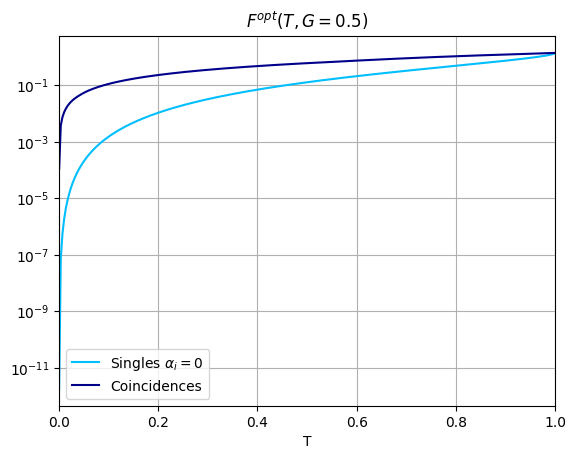

In [1]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
# Use __file__ if running as a script, or fallback to the current working directory if in Jupyter
current_dir = Path(__file__).resolve() if '__file__' in locals() else Path.cwd()
# Go up two levels to get the root directory
root_dir = current_dir.parents[1] if '__file__' in locals() else current_dir.parent
# Safely inject the directory to Python's search path
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))
from singles import OptimalPhase, OptFisherInfo
from coincidences import FisherInfo
from tqdm import tqdm


G=0.5                               #? Gain
T=np.linspace(0.0001,0.999,300)     #? T
t_s1=np.sqrt(T)                     #? τ_s1
t_i1=np.sqrt(T)                     #? τ_i1
t_s2=np.sqrt(T)                     #? τ_s2
t_i2=t_s2                           #? τ_i2  
a_i=1

F_noseed = OptFisherInfo(a_i=0,G=G,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2)
F_seed = OptFisherInfo(a_i=a_i,G=G,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2)

T_coin = np.linspace(T.min(),T.max(), 300)
F_coin = np.zeros_like(T_coin)
phi_approx = OptimalPhase(a_i=0,G=G,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2)
nmax = 15

for i,t in tqdm(np.ndenumerate(np.sqrt(T_coin))):
    phi_probe = np.linspace(phi_approx[i],np.pi,5)
    F_probe = np.zeros_like(phi_probe)
    for j in range(3):
        F_probe[j]=FisherInfo(nmax,phi=phi_probe[j], G=G, t_s1=1, t_i1=t, t_s2=1, t_i2=1)
    F_coin[i] = F_probe.max()

fig,ax = plt.subplots()
ax.plot(T,F_noseed, color="deepskyblue", label=r"Singles $\alpha_i=0$")
ax.plot(T_coin,F_coin, color="darkblue", label="Coincidences")
ax.set_title(rf"$F^{{opt}}(T,G={G})$")
ax.set_xlabel('T')
ax.set_xlim([0,1])
ax.set_yscale("log")
ax.grid(True)
ax.legend()


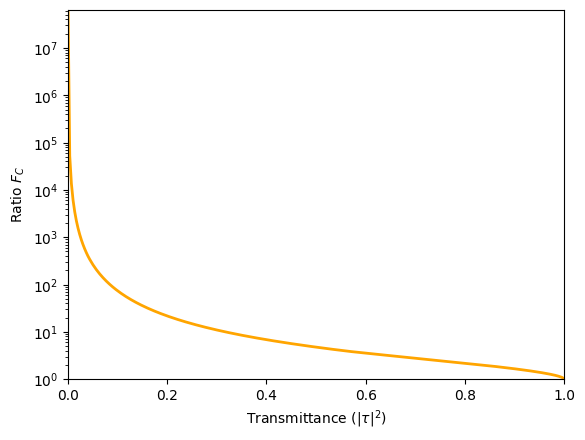

In [2]:
fig,ax = plt.subplots()
ax.plot(T_coin,F_coin/F_noseed, color="orange", linewidth=2)
ax.set_xlabel(r'Transmittance ($|\tau|^2$)')
ax.set_ylabel(r'Ratio $F_C$')
ax.set_xlim([0,1])
ax.set_ylim(bottom=1)
ax.set_yscale("log")